In [1]:
from importlib import reload
from importlib.resources import files, as_file

import numpy as np
import jax
import recovar
from recovar import (
    plot_utils, 
    output,
    simulator,
    utils,
    dataset,
    em,
    regularization, 
    synthetic_dataset,
    utils,
    noise

)
import time
import matplotlib.pyplot as plt
import seaborn as sns

reload(simulator)

# Dataset parameters
grid_size = 64
n_images = 1000
generate_data = True
noise_level = 10

# Input/output paths
volume_folder_input = str(files(recovar) / "data" / "vol")
output_folder = "/tmp/em_test/"

# Dataset generation parameters
volume_distribution = np.array([1, 0, 0])
voxel_size = 4.25 * 128 / grid_size

# Create output directory
output.mkdir_safe(output_folder)

if generate_data:
    image_stack, sim_info = simulator.generate_synthetic_dataset(output_folder, voxel_size, volume_folder_input, n_images,
                                                                    outlier_file_input = None, grid_size = grid_size,
                                    volume_distribution = volume_distribution,  dataset_params_option = "uniform", noise_level = noise_level,
                                    noise_model = "white", put_extra_particles = False, percent_outliers = 0.00, 
                                    volume_radius = 0.7, trailing_zero_format_in_vol_name = True, noise_scale_std =0, contrast_std = 0  , disc_type = 'nufft', n_tilts = -1 )
    print(f"Finished generating dataset {output_folder}")


/home/mg6942/.local/lib/python3.11/site-packages/finufft/_interfaces.py:329: UserWarning: Argument `x` does not satisfy the following requirement: C. Copying array (this may reduce performance)
  warnings.warn(f"Argument `{name}` does not satisfy the following requirement: {prop}. Copying array (this may reduce performance)")
/home/mg6942/.local/lib/python3.11/site-packages/finufft/_interfaces.py:329: UserWarning: Argument `y` does not satisfy the following requirement: C. Copying array (this may reduce performance)
  warnings.warn(f"Argument `{name}` does not satisfy the following requirement: {prop}. Copying array (this may reduce performance)")
/home/mg6942/.local/lib/python3.11/site-packages/finufft/_interfaces.py:329: UserWarning: Argument `z` does not satisfy the following requirement: C. Copying array (this may reduce performance)
  warnings.warn(f"Argument `{name}` does not satisfy the following requirement: {prop}. Copying array (this may reduce performance)")
/home/mg6942/.lo

Finished generating dataset /tmp/em_test/


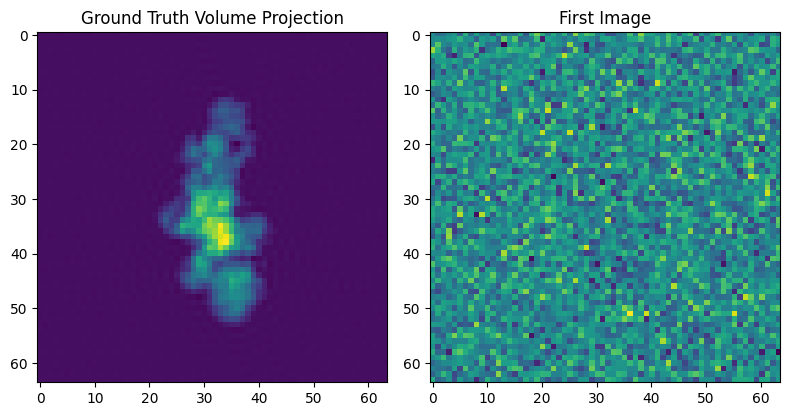

Number of integrations points: 479232, rotations: 36864, translations: 13
Number of images: 1000 of size (64, 64)


In [2]:
# Set up rotations and translation grids
healpix_order = 3
angles = em.sampling.get_rotation_grid(healpix_order)
rotation_grid = utils.R_from_relion(angles)
translation_grid = em.sampling.get_translation_grid(2, 1)

# Load dataset
dataset_dict = dataset.get_default_dataset_option()
dataset_dict.update({
    'ctf_file': output_folder + "ctf.pkl",
    'poses_file': output_folder + "poses.pkl", 
    'particles_file': f"{output_folder}particles.{grid_size}.mrcs"
})
cryo = dataset.load_dataset_from_dict(dataset_dict, lazy=False)

# Load ground truth data
sim_info = utils.pickle_load(output_folder + '/simulation_info.pkl')
gt_recon = synthetic_dataset.load_heterogeneous_reconstruction(sim_info)
gt_vol = gt_recon.volumes
noise_variance = sim_info['noise_variance']

# Get mean volume and signal variance
gt_results = synthetic_dataset.load_heterogeneous_reconstruction(sim_info)
gt_vol = gt_results.get_mean()
signal_variance_radial = regularization.average_over_shells(np.abs(gt_vol)**2, gt_results.volume_shape) 
signal_variance = utils.make_radial_image(signal_variance_radial, gt_results.volume_shape)

# Downsample to 5 fourier shells for initialization
downsampled_gt = gt_vol * cryo.get_valid_frequency_indices(rad=3)

# Gt volume and one image
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
ax1.imshow(cryo.get_proj(gt_vol.reshape(-1)))
ax1.set_title('Ground Truth Volume Projection')
ax2.imshow(cryo.get_image_real(0))
ax2.set_title('First Image')
plt.tight_layout()
plt.show()

print(f"Number of integrations points: {rotation_grid.shape[0] * translation_grid.shape[0]}, rotations: {rotation_grid.shape[0]}, translations: {translation_grid.shape[0]}")
print(f"Number of images: {cryo.n_units} of size {cryo.image_shape}")


In [3]:
### Test an E - step at the gt volume

# Compute noise variance radially
noise_variance_rad = noise.make_radial_noise(noise_variance, cryo.image_shape)

# Initialize parameters
disc_type = 'linear_interp'
# Compute probabilities
start_time = time.time()
probs = em.E_with_precompute(cryo, gt_vol, rotation_grid, translation_grid, 
                                     noise_variance_rad, disc_type)


hard_assignment = np.argmax(probs.reshape(probs.shape[0], -1), axis=-1)
# Estimate errors using em.core
error = em.core.estimate_error_from_hard_assignment(hard_assignment, cryo.rotation_matrices, cryo.translations, rotation_grid, translation_grid)
print(f"Rotation error: {error[0]} degrees and translation error: {error[1]} pixels")
print(f"Time elapsed: {time.time() - start_time:.2f}s")

Rotation error: 64.17504760791782 degrees and translation error: 0.7325584412271571 pixels
Time elapsed: 10.77s


/home/mg6942/.conda/envs/recovar_dev/lib/python3.11/site-packages/jax/_src/ops/scatter.py:92: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=complex128 to dtype=complex64 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(
/home/mg6942/.conda/envs/recovar_dev/lib/python3.11/site-packages/jax/_src/ops/scatter.py:92: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=float64 to dtype=complex64 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(


Iteration 1/5:
Rotation error: 119.21°
Translation error: 1.80 pixels
Iteration time: 11.65s
------------------------------
Iteration 2/5:
Rotation error: 119.94°
Translation error: 1.75 pixels
Iteration time: 9.46s
------------------------------
Iteration 3/5:
Rotation error: 119.10°
Translation error: 1.75 pixels
Iteration time: 8.32s
------------------------------
Iteration 4/5:
Rotation error: 119.20°
Translation error: 1.75 pixels
Iteration time: 8.52s
------------------------------
Iteration 5/5:
Rotation error: 119.66°
Translation error: 1.74 pixels
Iteration time: 8.36s
------------------------------


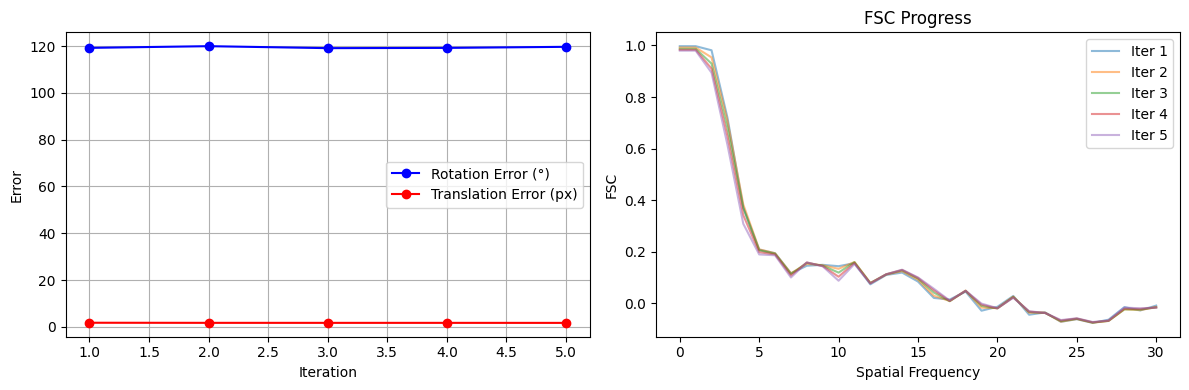

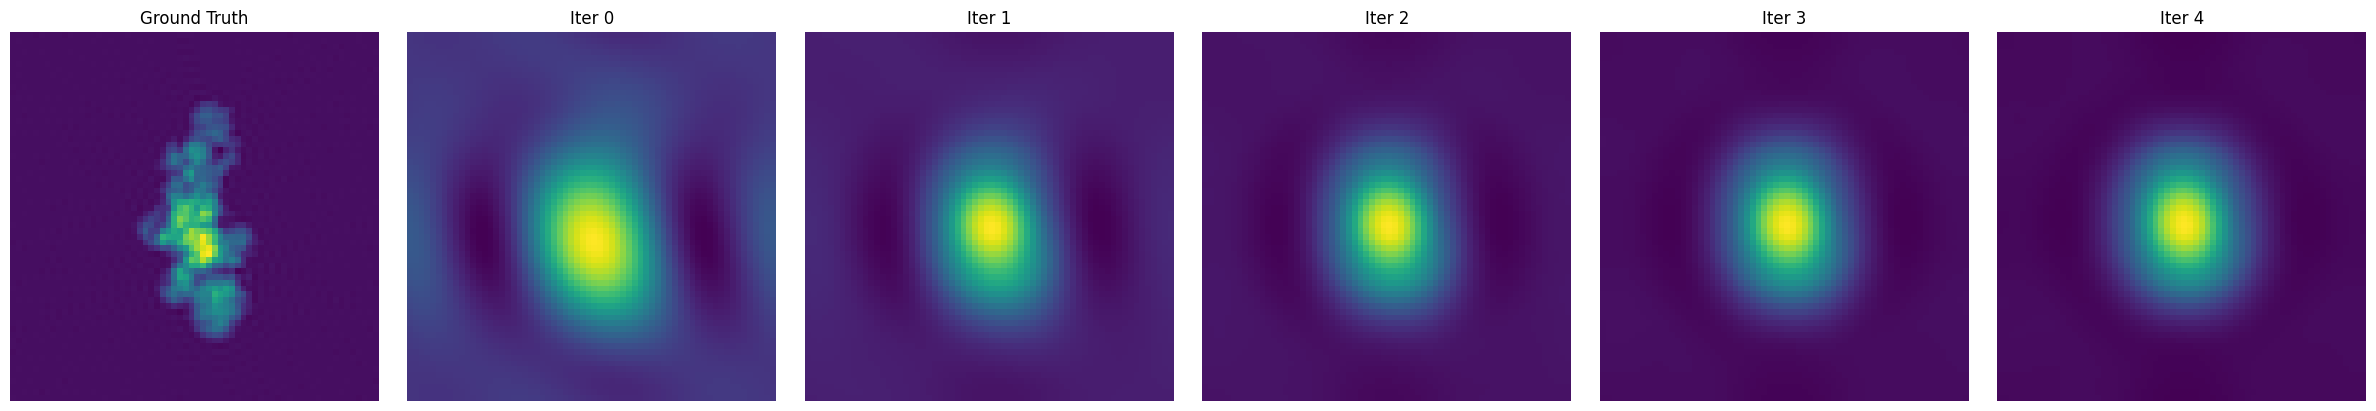


Total time elapsed: 46.80s
Average iteration time: 9.26s


In [4]:
### A simple EM iteration. 

# Initialize parameters
disc_type_mean = disc_type
disc_type_u = disc_type
estimate = downsampled_gt.copy()

# Set up parameters
n_iterations = 5
rotation_errors = []
translation_errors = []
fscs = []
iteration_times = []
iterates = [estimate.copy()]  # Store initial estimate
start_time = time.time()

for k in range(n_iterations):
    iter_start = time.time()
    
    # E-step
    mean_prior = 1/signal_variance
    probs = em.E_with_precompute(cryo, estimate, rotation_grid, translation_grid, 
                                noise_variance_rad, disc_type)     

    # M-step
    Ft_y_this, Ft_CTF_this = em.M_with_precompute(cryo, probs, rotation_grid, 
                                                  translation_grid, noise_variance_rad, disc_type)
    
    # Update estimate, dont update the prior
    estimate = Ft_y_this / (Ft_CTF_this + mean_prior)
    iterates.append(estimate.copy())  # Store each iterate

    # Calculate FSC and errors
    fsc = plot_utils.FSC(gt_vol.reshape(cryo.volume_shape), estimate.reshape(cryo.volume_shape))
    fscs.append(fsc)
    
    hard_assignment = np.argmax(probs.reshape(probs.shape[0], -1), axis=-1)
    rot_err, trans_err = em.core.estimate_error_from_hard_assignment(
        hard_assignment, cryo.rotation_matrices, cryo.translations, 
        rotation_grid, translation_grid)
    
    rotation_errors.append(rot_err)
    translation_errors.append(trans_err)
    iteration_times.append(time.time() - iter_start)

    print(f"Iteration {k+1}/{n_iterations}:")
    print(f"Rotation error: {rot_err:.2f}°")
    print(f"Translation error: {trans_err:.2f} pixels")
    print(f"Iteration time: {iteration_times[-1]:.2f}s")
    print("-" * 30)

# Plot errors and FSC
fig1, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot errors
axes[0].plot(range(1, n_iterations+1), rotation_errors, 'b-o', label='Rotation Error (°)')
axes[0].plot(range(1, n_iterations+1), translation_errors, 'r-o', label='Translation Error (px)')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Error')
axes[0].legend()
axes[0].grid(True)

# Plot FSC progression
for i, fsc in enumerate(fscs):
    axes[1].plot(fsc, label=f'Iter {i+1}', alpha=0.5)
axes[1].set_title('FSC Progress')
axes[1].set_xlabel('Spatial Frequency')
axes[1].set_ylabel('FSC')
axes[1].legend()

plt.tight_layout()
plt.show()

# Plot ground truth and iterates in a separate figure
fig2, axes = plt.subplots(1, 6, figsize=(24, 4))

# Plot ground truth
axes[0].imshow(cryo.get_proj(gt_vol.reshape(-1)))
axes[0].set_title('Ground Truth')
axes[0].axis('off')

# Plot iterates
for i in range(5):
    axes[i+1].imshow(cryo.get_proj(iterates[i].reshape(-1)))
    axes[i+1].set_title(f'Iter {i}')
    axes[i+1].axis('off')

plt.tight_layout()
plt.show()

print(f"\nTotal time elapsed: {time.time() - start_time:.2f}s")
print(f"Average iteration time: {np.mean(iteration_times):.2f}s")


Finished processing all batches
Iteration 1
Rotation error: 119.21°
Translation error: 1.80 pixels
Iteration time: 23.72s
------------------------------
Finished processing all batches
Iteration 2
Rotation error: 121.42°
Translation error: 1.77 pixels
Iteration time: 10.46s
------------------------------
Finished processing all batches
Iteration 3
Rotation error: 120.56°
Translation error: 1.70 pixels
Iteration time: 10.06s
------------------------------
Finished processing all batches
Iteration 4
Rotation error: 121.32°
Translation error: 1.68 pixels
Iteration time: 10.30s
------------------------------
Finished processing all batches
Iteration 5
Rotation error: 120.95°
Translation error: 1.66 pixels
Iteration time: 10.20s
------------------------------
Finished processing all batches
Iteration 6
Rotation error: 120.79°
Translation error: 1.65 pixels
Iteration time: 10.21s
------------------------------
Finished processing all batches
Iteration 7
Rotation error: 120.36°
Translation er

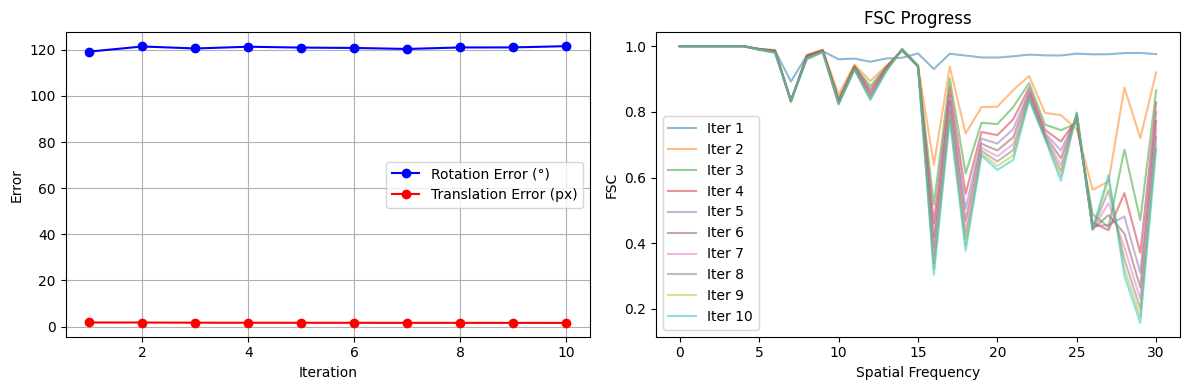

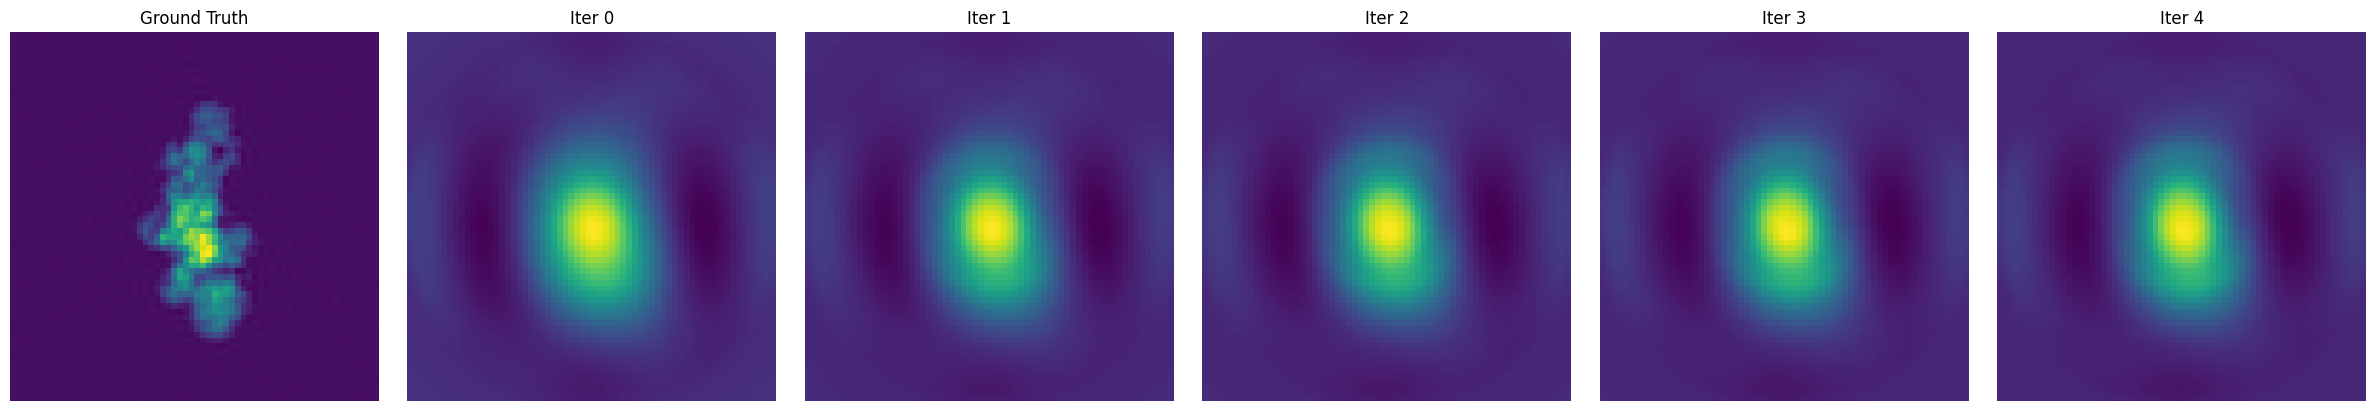

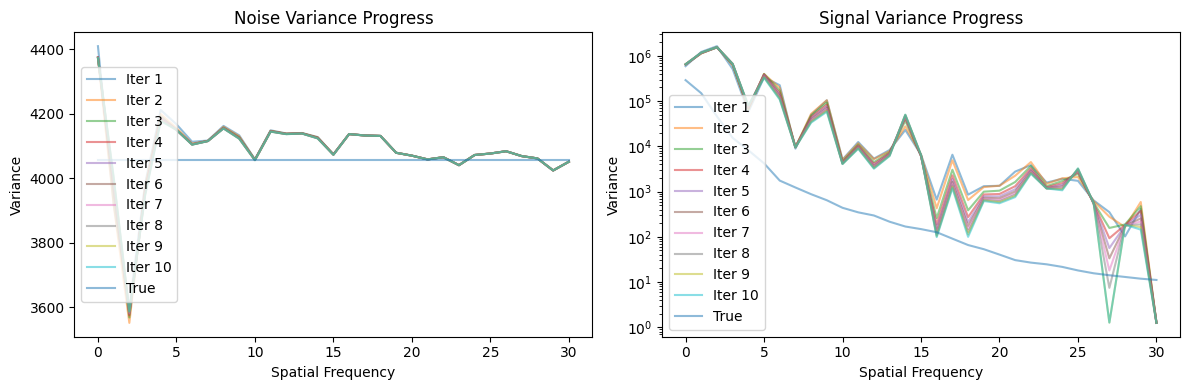


Total time elapsed: 117.11s
Average iteration time: 11.61s


In [5]:
# A more sophisticated EM implementation based on the RELION implementation.
# Split data into halfsets and run EM iterations on each half independently
# There are likely some bugs in here.
from recovar import dataset
reload(dataset)
reload(em)

# Split indices into two halves
ind = np.arange(n_images)
ind = [ind[:n_images//2], ind[n_images//2:]]
if 'ind' in dataset_dict:
    del dataset_dict['ind']

# Load split datasets
cryos = dataset.get_split_datasets_from_dict(dataset_dict, ind_split=ind, lazy=False)

# Initialize parameters
noise_variance = noise_variance_rad
init_frequency_pixels = 3
init = gt_vol * cryo.get_valid_frequency_indices(init_frequency_pixels)

# Calculate signal variance
mean_signal_variance = utils.make_radial_image(
    regularization.average_over_shells(np.abs(gt_vol)**2, gt_vol.shape), 
    gt_vol.shape
)

# Get shapes and ground truth poses
volume_shape = cryos[0].volume_shape
image_shape = cryos[0].image_shape
gt_poses = np.concatenate([cryo.rotation_matrices for cryo in cryos], axis=0)
gt_trans = np.concatenate([cryo.translations for cryo in cryos], axis=0)

from recovar.em import EMState

# Initialize states and tracking variables
state_objs = [EMState(init.reshape(-1), mean_signal_variance, noise_variance_rad) for _ in range(2)]
all_means = []  # Initialize as empty list
angle_errors = []
trans_errors = []
iteration_times = []
fscs = []
noise_variances = []
signal_variances = []

# This is an option to average up the two halfmaps at each iteration to make sure they stay aligned. This is done in RELION.
# Passing None won't do it. It's not necessary here.
average_up_to_fourier_shells = 5
start_time = time.time()
n_iterations = 10
for k in range(n_iterations):
    iter_start = time.time()
    
    # Run E and M steps on both halfsets
    state_objs, current_pixel_res, hard_assignments = em.split_E_M_v2(
        cryos, state_objs, rotation_grid, translation_grid, disc_type, 
        average_up_to_angstrom=average_up_to_fourier_shells
    )
    
    # Store means and update resolution threshold
    means = [state_obj.mean for state_obj in state_objs]
    all_means.append((means[0] + means[1])/2)  # Store only first halfset mean

    noise_variances.append( regularization.average_over_shells(state_objs[0].noise_variance, cryos[0].image_shape) ) 
    signal_variances.append( regularization.average_over_shells(state_objs[0].mean_variance, cryos[0].volume_shape) ) 
    # Calculate FSC
    fsc = regularization.get_fsc_gpu(means[0], means[1], volume_shape, substract_shell_mean=False, frequency_shift=0)
    fscs.append(fsc)

    # Calculate and store errors
    angle_error, trans_error = em.core.estimate_error_from_hard_assignment(
        np.concatenate(hard_assignments).astype(int), gt_poses, gt_trans, rotation_grid, translation_grid
    )
    angle_errors.append(angle_error)
    trans_errors.append(trans_error)
    
    # Store iteration time
    iteration_times.append(time.time() - iter_start)

    print(f"Iteration {k+1}")
    print(f"Rotation error: {angle_error:.2f}°")
    print(f"Translation error: {trans_error:.2f} pixels")
    print(f"Iteration time: {iteration_times[-1]:.2f}s")
    print("-" * 30)

# Plot errors and FSC
fig1, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot errors
axes[0].plot(range(1, n_iterations+1), angle_errors, 'b-o', label='Rotation Error (°)')
axes[0].plot(range(1, n_iterations+1), trans_errors, 'r-o', label='Translation Error (px)')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Error')
axes[0].legend()
axes[0].grid(True)

# Plot FSC progression
for i, fsc in enumerate(fscs):
    axes[1].plot(fsc, label=f'Iter {i+1}', alpha=0.5)
axes[1].set_title('FSC Progress')
axes[1].set_xlabel('Spatial Frequency')
axes[1].set_ylabel('FSC')
axes[1].legend()

plt.tight_layout()
plt.show()

# Plot ground truth and iterates in a separate figure
fig2, axes = plt.subplots(1, 6, figsize=(24, 4))

# Plot ground truth
axes[0].imshow(cryo.get_proj(gt_vol.reshape(-1)))
axes[0].set_title('Ground Truth')
axes[0].axis('off')

# Plot iterates
for i in range(5):
    axes[i+1].imshow(cryo.get_proj(all_means[i].reshape(-1)))
    axes[i+1].set_title(f'Iter {i}')
    axes[i+1].axis('off')

plt.tight_layout()
plt.show()

# Plot noise and signal variances
fig3, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot noise variance progression
for i, noise_var in enumerate(noise_variances):
    axes[0].plot(noise_var, label=f'Iter {i+1}', alpha=0.5)
noise_variance_gt = sim_info['noise_variance']
axes[0].plot(noise_variance_gt, label=f'True', alpha=0.5)
axes[0].set_title('Noise Variance Progress')
axes[0].set_xlabel('Spatial Frequency')
axes[0].set_ylabel('Variance')
axes[0].legend()

# Plot signal variance progression
for i, signal_var in enumerate(signal_variances):
    axes[1].semilogy(signal_var, label=f'Iter {i+1}', alpha=0.5)
axes[1].semilogy(signal_variance_radial, label=f'True', alpha=0.5)

axes[1].set_title('Signal Variance Progress')
axes[1].set_xlabel('Spatial Frequency')
axes[1].set_ylabel('Variance')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nTotal time elapsed: {time.time() - start_time:.2f}s")
print(f"Average iteration time: {np.mean(iteration_times):.2f}s")

